# Projekt 01 (basic): SQL — Daten holen, wo sie wohnen

**Ziel:** Die SQL-Grundbausteine (SELECT, WHERE, GROUP BY, JOIN, HAVING) an einer
richtigen Datenbank ueben — und nebenbei sehen, wie SQL und pandas zusammenspielen.

**Vorbereitung** (einmalig, im Ordner `01-basic`, venv aktiv):

```
python generate_db.py
```

Das erzeugt `datasets/shop.db`: eine SQLite-Datenbank mit einem fiktiven Online-Shop —
**60 Kunden, 25 Produkte, 800 Bestellungen** in drei verknuepften Tabellen:

```
kunden(kunden_id, name, stadt, registriert_am)
produkte(produkt_id, name, kategorie, preis)
bestellungen(bestell_id, kunden_id -> kunden, produkt_id -> produkte, menge, bestellt_am)
```

Beachte das Prinzip: Die Bestellung speichert nur *Verweise* (Fremdschluessel) auf
Kunde und Produkt — Namen und Preise stehen genau einmal in ihren eigenen Tabellen
(Normalisierung). Um "Umsatz pro Stadt" zu beantworten, muss man die Tabellen
**joinen** — genau das uebst du hier.

**Bezug zum Skript:** Abschnitt 2.4 (SQL). Tipp vorab: 15 Minuten https://sqlbolt.com.

## 1. Verbindung aufbauen

SQLite ist in Python eingebaut; `pd.read_sql` fuehrt eine Abfrage aus und liefert
das Ergebnis direkt als DataFrame. Die Hilfsfunktion `q(...)` spart Tipparbeit.

In [1]:
import os
import sqlite3
import pandas as pd

PFAD = "datasets/shop.db" if os.path.exists("datasets/shop.db") else "../datasets/shop.db"
con = sqlite3.connect(PFAD)

def q(sql):
    """Fuehrt eine SQL-Abfrage aus und liefert einen DataFrame."""
    return pd.read_sql(sql, con)

q("SELECT name FROM sqlite_master WHERE type = 'table'")

,name
0,kunden
1,produkte
2,bestellungen


## 2. SELECT, WHERE, ORDER BY, LIMIT

Erstes Muster: Zeilen auswaehlen, filtern, sortieren, begrenzen.

```sql
SELECT spalte1, spalte2 FROM tabelle WHERE bedingung ORDER BY spalte DESC LIMIT 5
```

**Aufgaben:**
1. Alle Produkte der Kategorie 'Buecher' — Name und Preis, nach Preis absteigend.
2. Wie viele Produkte kosten mehr als 50 EUR? (`COUNT(*)`)
3. Die 5 juengsten Bestellungen (nach `bestellt_am`).

In [2]:
# Aufgabe 1:
q("SELECT name, preis FROM produkte WHERE kategorie = 'Buecher' ORDER BY preis DESC")

,name,preis
0,Data-Science-Praxis,44.95
1,Python-Handbuch,39.95
2,Statistik-Grundkurs,29.95
3,SQL fuer Einsteiger,24.95
4,KI-Ueberblick,19.95
5,Roman Bestseller,12.95


In [3]:
# Aufgaben 2 und 3:
teuer = q("SELECT COUNT(*) AS anzahl FROM produkte WHERE preis > 50")
neueste = q("SELECT * FROM bestellungen ORDER BY bestellt_am DESC LIMIT 5")
print(neueste)

# Mini-Check:
print(int(teuer["anzahl"][0]) == 6)

   bestell_id  kunden_id  produkt_id  menge bestellt_am
0         114         26          21      1  2024-12-28
1         557         26          15      2  2024-12-28
2         634         40           7      1  2024-12-28
3         699         48           5      3  2024-12-28
4          50          9          13      4  2024-12-27
True


## 3. GROUP BY — Aggregieren wie groupby

**Aufgaben:**
1. Wie viele Produkte gibt es pro Kategorie? (`COUNT(*)`, `GROUP BY`)
2. Durchschnittspreis pro Kategorie, absteigend sortiert (`AVG`, `ROUND(x, 2)`).
3. Bestellungen pro Monat: `strftime('%m', bestellt_am)` extrahiert den Monat —
   gibt es einen Dezember-Peak?

    kategorie  anzahl
0     Buecher       6
1  Elektronik       8
2    Haushalt       6
3       Sport       5
    kategorie  mittelpreis
0  Elektronik        71.74
1    Haushalt        49.99
2     Buecher        28.78
3       Sport        22.99


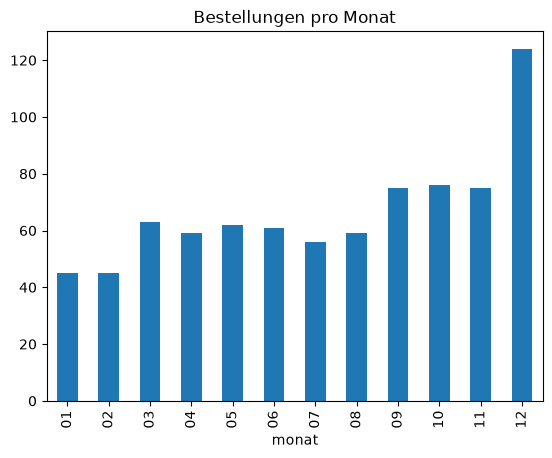

In [4]:
print(q("SELECT kategorie, COUNT(*) AS anzahl FROM produkte GROUP BY kategorie"))
print(q("""SELECT kategorie, ROUND(AVG(preis), 2) AS mittelpreis
           FROM produkte GROUP BY kategorie ORDER BY mittelpreis DESC"""))
monate = q("""SELECT strftime('%m', bestellt_am) AS monat, COUNT(*) AS anzahl
              FROM bestellungen GROUP BY monat ORDER BY monat""")
monate.plot.bar(x="monat", y="anzahl", legend=False, title="Bestellungen pro Monat");

## 4. JOIN — Tabellen verknuepfen

Der eigentliche Grund, warum die Daten in drei Tabellen liegen. Muster:

```sql
SELECT ... FROM bestellungen b
JOIN kunden   k ON k.kunden_id  = b.kunden_id
JOIN produkte p ON p.produkt_id = b.produkt_id
```

**Aufgaben:**
1. Anzahl Bestellungen pro **Stadt** (braucht: bestellungen ⋈ kunden).
2. **Umsatz** (= `p.preis * b.menge`) pro **Kategorie**, absteigend.
3. Die **Top-3-Kunden** nach Umsatz (Name + Umsatz; braucht alle drei Tabellen!).

In [5]:
print(q("""SELECT k.stadt, COUNT(*) AS anzahl
           FROM bestellungen b JOIN kunden k ON k.kunden_id = b.kunden_id
           GROUP BY k.stadt ORDER BY anzahl DESC"""))
umsatz_kat = q("""SELECT p.kategorie, ROUND(SUM(p.preis * b.menge), 2) AS umsatz
                  FROM bestellungen b JOIN produkte p ON p.produkt_id = b.produkt_id
                  GROUP BY p.kategorie ORDER BY umsatz DESC""")
print(umsatz_kat)
top3 = q("""SELECT k.name, ROUND(SUM(p.preis * b.menge), 2) AS umsatz
            FROM bestellungen b
            JOIN produkte p ON p.produkt_id = b.produkt_id
            JOIN kunden   k ON k.kunden_id  = b.kunden_id
            GROUP BY k.kunden_id ORDER BY umsatz DESC LIMIT 3""")
print(top3)

# Mini-Checks:
print(umsatz_kat["kategorie"][0] == "Elektronik")          # umsatzstaerkste Kategorie
print(top3["name"][0] == "Emma Schulz")                    # Top-Kundin

      stadt  anzahl
0   Leipzig     176
1    Berlin     172
2   Hamburg     157
3     Koeln     150
4  Muenchen     145
    kategorie    umsatz
0  Elektronik  28851.83
1    Haushalt  13572.22
2     Buecher   8356.90
3       Sport   5587.54
            name   umsatz
0    Emma Schulz  2645.26
1  Samuel Becker  1810.35
2  Tilda Mueller  1763.58
True
True


## 5. LEFT JOIN — wer fehlt?

Ein `JOIN` (INNER) zeigt nur Kunden, die auch bestellt haben. Marketing fragt aber:
**"Welche Kunden haben noch NIE bestellt?"** Dafuer: `LEFT JOIN` (alle Kunden behalten,
Bestellspalten sind dann `NULL`) plus `WHERE b.bestell_id IS NULL`.

**Aufgabe:** Finde diese Kunden (Name, Stadt). Es sollten **5** sein.

In [6]:
karteileichen = q("""SELECT k.name, k.stadt
                     FROM kunden k
                     LEFT JOIN bestellungen b ON b.kunden_id = k.kunden_id
                     WHERE b.bestell_id IS NULL""")
print(karteileichen)
print(len(karteileichen) == 5)

             name     stadt
0     Tilda Meyer  Muenchen
1    Leon Schmidt   Hamburg
2    Paul Fischer     Koeln
3  Tilda Hoffmann  Muenchen
4   Clara Schmidt   Hamburg
True


## 6. WHERE vs. HAVING

`WHERE` filtert Zeilen **vor** der Gruppierung, `HAVING` filtert Gruppen **danach** —
nur dort darf `COUNT(*)` & Co. stehen (Skript 2.4, Selbsttest-Frage 7!).

**Aufgabe:** Welche Staedte haben 150 oder mehr Bestellungen? (Erwartet: 4 Staedte.)
Probiere zuerst absichtlich `WHERE COUNT(*) >= 150` — lies die Fehlermeldung.

In [7]:
staedte = q("""SELECT k.stadt, COUNT(*) AS anzahl
               FROM bestellungen b JOIN kunden k ON k.kunden_id = b.kunden_id
               GROUP BY k.stadt
               HAVING COUNT(*) >= 150
               ORDER BY anzahl DESC""")
print(staedte)
print(len(staedte) == 4)

     stadt  anzahl
0  Leipzig     176
1   Berlin     172
2  Hamburg     157
3    Koeln     150
True


## 7. Arbeitsteilung SQL + pandas

Faustregel aus dem Skript: **Filtern/Joinen in SQL, Analysieren/Plotten in pandas.**
So sieht der typische Workflow aus — SQL liefert die kompakte Analysetabelle,
pandas macht den Rest (fertig vorgegeben):

kategorie  Buecher  Elektronik  Haushalt   Sport
stadt                                           
Berlin      2011.0      4873.0    2574.0  1424.0
Hamburg     2117.0      5300.0    2634.0  1320.0
Koeln       1186.0      5389.0    2919.0   570.0
Leipzig     1577.0      8640.0    2654.0  1514.0
Muenchen    1465.0      4649.0    2789.0   760.0


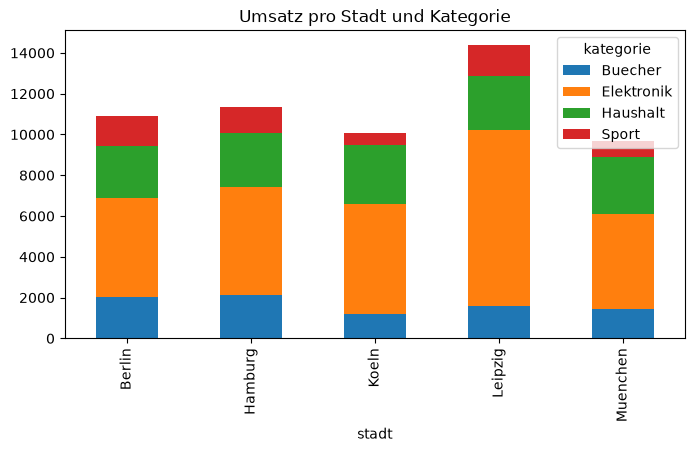

In [8]:
analyse = q("""SELECT b.bestellt_am, k.stadt, p.kategorie,
                      p.preis * b.menge AS umsatz
               FROM bestellungen b
               JOIN kunden   k ON k.kunden_id  = b.kunden_id
               JOIN produkte p ON p.produkt_id = b.produkt_id""")
analyse["bestellt_am"] = pd.to_datetime(analyse["bestellt_am"])

pivot = analyse.pivot_table(index="stadt", columns="kategorie",
                            values="umsatz", aggfunc="sum").round(0)
print(pivot)
pivot.plot.bar(stacked=True, figsize=(8, 4), title="Umsatz pro Stadt und Kategorie");

In [9]:
con.close()   # Verbindung am Ende immer schliessen

## Geschafft — was du jetzt kannst

- SELECT / WHERE / ORDER BY / LIMIT, Aggregation mit GROUP BY
- Tabellen ueber Fremdschluessel joinen (INNER und LEFT) — und wissen, wann welcher
- WHERE vs. HAVING sicher unterscheiden
- SQL-Ergebnisse nahtlos in pandas weiterverarbeiten

**Bonusaufgaben** (optional):
1. Umsatz pro Monat als SQL-Abfrage (strftime + JOIN + SUM) — und als Linienplot.
2. Welcher Kunde hat die meisten *verschiedenen* Produkte gekauft? (`COUNT(DISTINCT ...)`)
3. Schreibe die Stadt-Bestellungen-Abfrage aus Abschnitt 4 einmal komplett in pandas
   nach (merge + groupby) und vergleiche die Ergebnisse.